# 🧪 Modèle de Régression – Prédiction du Turnaround Time

Ce notebook prédit le `turnaround_time_mins` (délai d'analyse en laboratoire) via plusieurs modèles de machine learning et un réseau de neurones.

## 1. Chargement et exploration des données

In [1]:
import pandas as pd
from datetime import datetime, timedelta

# Charger le dataset
df = pd.read_csv("lab_pred.csv")
print(f"Dimensions : {df.shape}")
df.head()

Dimensions : (427945, 11)


,labid,labname,result_time,validation_time,turnaround_time_mins,gender,age,unittype,admissionweight,recent_diagnosis,lab_workload_last_hour
0,44971395,potassium,-5070,-5027,43,Female,> 89,Med-Surg ICU,48.1,NaN,31
1,44971397,alkaline phos.,-5070,-5027,43,Female,> 89,Med-Surg ICU,48.1,NaN,31
2,51000461,Hgb,-5070,-5048,22,Female,> 89,Med-Surg ICU,48.1,NaN,31
3,44971404,calcium,-5070,-5027,43,Female,> 89,Med-Surg ICU,48.1,NaN,31
4,44971402,bicarbonate,-5070,-5027,43,Female,> 89,Med-Surg ICU,48.1,NaN,31


In [2]:
# Conversion des colonnes temps (minutes depuis référence) en datetime
reference_date = datetime(2026, 5, 1, 0, 0, 0)
df["result_time"]     = df["result_time"].apply(lambda x: reference_date + timedelta(minutes=x))
df["validation_time"] = df["validation_time"].apply(lambda x: reference_date + timedelta(minutes=x))
df.head()

,labid,labname,result_time,validation_time,turnaround_time_mins,gender,age,unittype,admissionweight,recent_diagnosis,lab_workload_last_hour
0,44971395,potassium,2026-04-27 11:30:00,2026-04-27 12:13:00,43,Female,> 89,Med-Surg ICU,48.1,NaN,31
1,44971397,alkaline phos.,2026-04-27 11:30:00,2026-04-27 12:13:00,43,Female,> 89,Med-Surg ICU,48.1,NaN,31
2,51000461,Hgb,2026-04-27 11:30:00,2026-04-27 11:52:00,22,Female,> 89,Med-Surg ICU,48.1,NaN,31
3,44971404,calcium,2026-04-27 11:30:00,2026-04-27 12:13:00,43,Female,> 89,Med-Surg ICU,48.1,NaN,31
4,44971402,bicarbonate,2026-04-27 11:30:00,2026-04-27 12:13:00,43,Female,> 89,Med-Surg ICU,48.1,NaN,31


In [3]:
# Exploration rapide
print(f"Nombre de lignes : {len(df)}")
print("\nValeurs manquantes :")
print(df.isnull().sum())
print("\nTypes de colonnes :")
print(df.dtypes)

Nombre de lignes : 427945

Valeurs manquantes :
labid                          0
labname                        0
result_time                    0
validation_time                0
turnaround_time_mins           0
gender                        80
age                           28
unittype                       0
admissionweight            15884
recent_diagnosis          131405
lab_workload_last_hour         0
dtype: int64

Types de colonnes :
labid                              int64
labname                           object
result_time               datetime64[ns]
validation_time           datetime64[ns]
turnaround_time_mins               int64
gender                            object
age                               object
unittype                          object
admissionweight                  float64
recent_diagnosis                  object
lab_workload_last_hour             int64
dtype: object


In [4]:
# Distribution de la target
top5 = df["turnaround_time_mins"].nlargest(5)
print("Top 5 turnaround times (min) :\n", top5)
print("\nStatistiques descriptives :")
print(df["turnaround_time_mins"].describe())

Top 5 turnaround times (min) :
 42237    93546
42238    93546
42239    93546
42240    93546
42241    93546
Name: turnaround_time_mins, dtype: int64

Statistiques descriptives :
count    427945.000000
mean         64.731606
std         766.427855
min           0.000000
25%           5.000000
50%          32.000000
75%          59.000000
max       93546.000000
Name: turnaround_time_mins, dtype: float64


In [5]:
# Distribution par genre
print(df["gender"].value_counts())

# Valeur la plus fréquente dans recent_diagnosis
print("\nValeur la plus fréquente dans recent_diagnosis :", df["recent_diagnosis"].mode()[0])
print("Nb occurrences :", df["recent_diagnosis"].value_counts().iloc[0])
print("Nb valeurs manquantes :", df["recent_diagnosis"].isnull().sum())

gender
Male      265560
Female    162305
Name: count, dtype: int64

Valeur la plus fréquente dans recent_diagnosis : pulmonary|respiratory failure|acute respiratory failure
Nb occurrences : 11649
Nb valeurs manquantes : 131405


## 2. Nettoyage des données

In [6]:
# Normalisation des colonnes textuelles
df["recent_diagnosis"] = df["recent_diagnosis"].str.lower().str.strip()
df["labname"]          = df["labname"].str.lower().str.strip()

# Remplacement des valeurs manquantes dans recent_diagnosis
df["recent_diagnosis"] = df["recent_diagnosis"].fillna("unknown")

# Corriger l'âge '> 89' → 90
df["age"] = df["age"].replace({"> 89": 90})
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["admissionweight"] = pd.to_numeric(df["admissionweight"], errors="coerce")

# Imputation des médianes
df["age"]             = df["age"].fillna(df["age"].median())
df["admissionweight"] = df["admissionweight"].fillna(df["admissionweight"].median())

print(f"Valeurs manquantes restantes : {df.isnull().sum().sum()}")
print(f"Valeurs uniques dans recent_diagnosis : {df['recent_diagnosis'].nunique()}")

Valeurs manquantes restantes : 80
Valeurs uniques dans recent_diagnosis : 705


## 3. Feature Engineering

In [7]:
# Extraction des features temporelles depuis result_time
df["result_year"]    = df["result_time"].dt.year
df["result_month"]   = df["result_time"].dt.month
df["result_day"]     = df["result_time"].dt.day
df["result_hour"]    = df["result_time"].dt.hour
df["result_weekday"] = df["result_time"].dt.weekday

# Catégorisation de l'heure
def categorize_hour(hour):
    if 6 <= hour < 12:   return "matin"
    elif 12 <= hour < 18: return "apres_midi"
    elif 18 <= hour < 24: return "soir"
    else:                  return "nuit"

# Catégorisation du jour
def categorize_weekday(day):
    return "weekend" if day in [5, 6] else "weekday"

# Catégorisation de la charge de travail
def categorize_workload(w):
    if w < 10:    return "faible"
    elif w < 30:  return "moyen"
    else:          return "eleve"

df["time_category"]     = df["result_hour"].apply(categorize_hour)
df["day_category"]      = df["result_weekday"].apply(categorize_weekday)
df["workload_category"] = df["lab_workload_last_hour"].apply(categorize_workload)

# Supprimer les colonnes datetime brutes
df = df.drop(columns=["result_time", "validation_time"])
print("Colonnes créées :", [c for c in df.columns if 'category' in c])

Colonnes créées : ['time_category', 'day_category', 'workload_category']


In [8]:
# Reconstitution datetime validation (pour enrichissement de la target)
df["result_datetime"] = pd.to_datetime(dict(
    year=df["result_year"], month=df["result_month"],
    day=df["result_day"],   hour=df["result_hour"]
))
df["estimated_validation_datetime"] = (
    df["result_datetime"] + pd.to_timedelta(df["turnaround_time_mins"], unit="m")
)
df["validation_hour"]     = df["estimated_validation_datetime"].dt.hour
df["turnaround_category"] = df["validation_hour"].apply(categorize_hour)

df["target_enriched"] = (
    df["estimated_validation_datetime"].dt.strftime("%d-%m") + " - " +
    df["turnaround_category"]
)
print(df[["turnaround_time_mins", "turnaround_category", "target_enriched"]].head())

   turnaround_time_mins turnaround_category target_enriched
0                    43               matin   27-04 - matin
1                    43               matin   27-04 - matin
2                    22               matin   27-04 - matin
3                    43               matin   27-04 - matin
4                    43               matin   27-04 - matin


## 4. Visualisation exploratoire

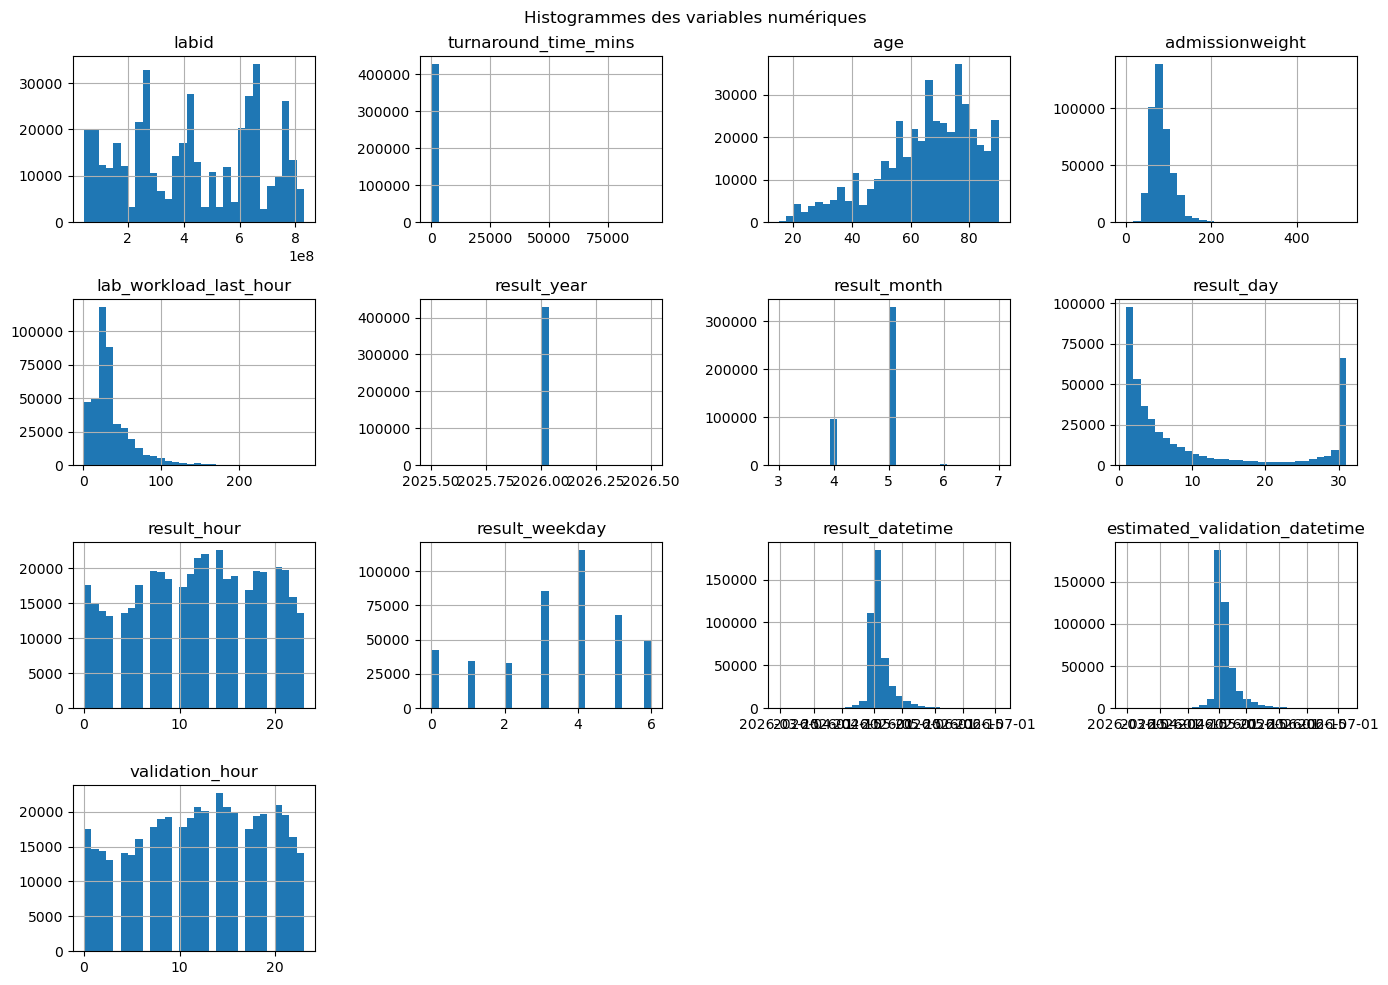

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogrammes des variables numériques
df.hist(figsize=(14, 10), bins=30)
plt.suptitle("Histogrammes des variables numériques")
plt.tight_layout()
plt.show()

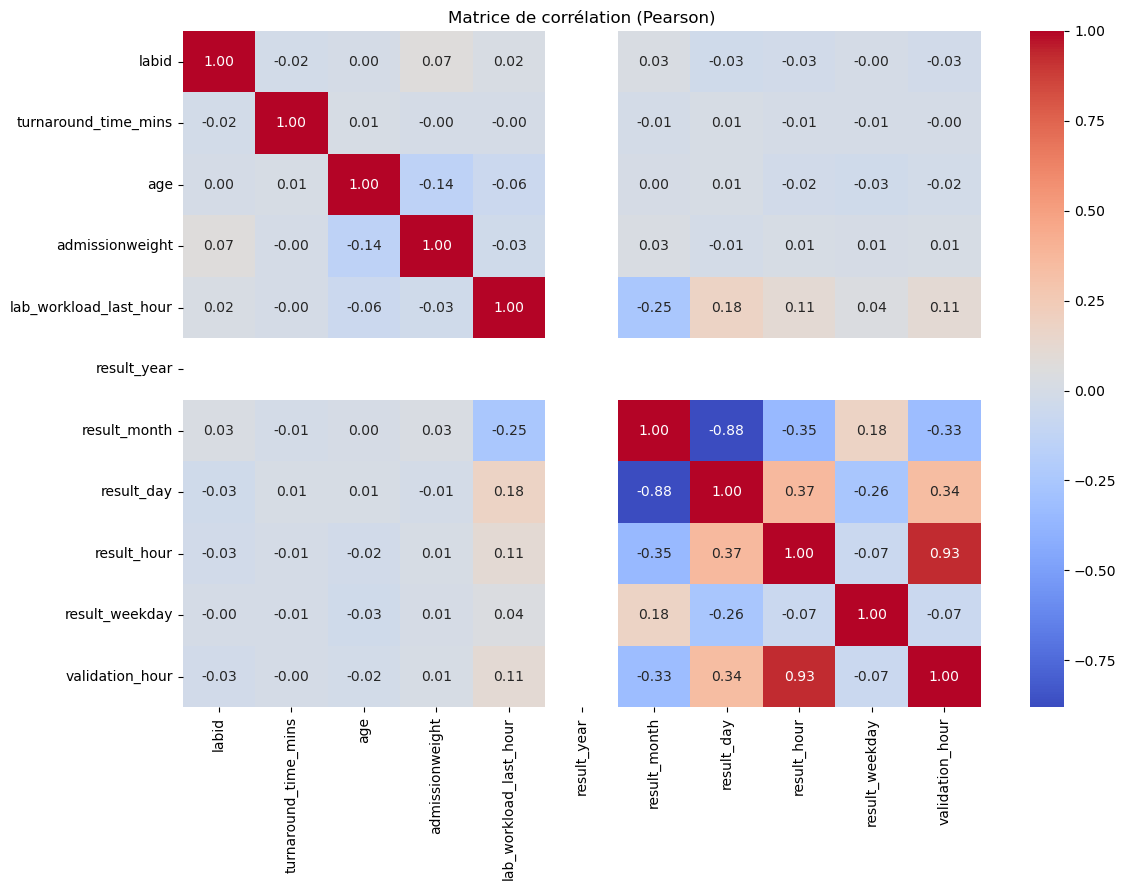


Corrélations avec turnaround_time_mins :
turnaround_time_mins      1.000000
age                       0.012360
result_day                0.008170
validation_hour          -0.001012
admissionweight          -0.002996
lab_workload_last_hour   -0.004385
result_weekday           -0.005978
result_hour              -0.006166
result_month             -0.011770
labid                    -0.017395
result_year                    NaN
Name: turnaround_time_mins, dtype: float64


In [10]:
# Matrice de corrélation
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de corrélation (Pearson)")
plt.tight_layout()
plt.show()

# Corrélations avec la target
print("\nCorrélations avec turnaround_time_mins :")
print(corr_matrix["turnaround_time_mins"].sort_values(ascending=False))

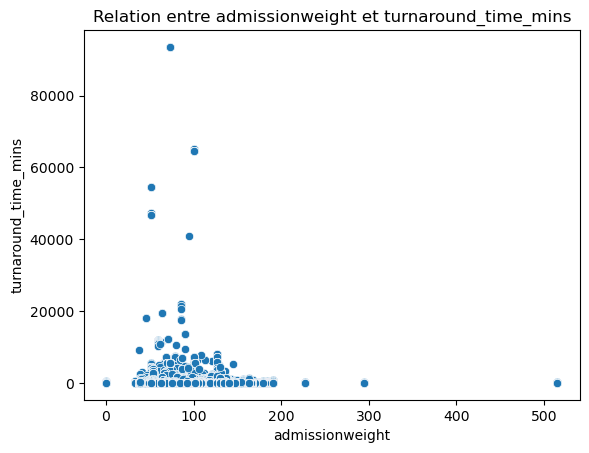

unittype                      CCU-CTICU  CSICU  CTICU  Cardiac ICU  MICU  \
labname                                                                    
-bands                               18      4      5           27   119   
-basos                              256    136     89          482   488   
-eos                                259    130     93          489   509   
-lymphs                             256    147     94          527   555   
-monos                              257    147     94          526   548   
...                                 ...    ...    ...          ...   ...   
wbc's in cerebrospinal fluid          0      0      0            2     1   
wbc's in peritoneal fluid             0      0      0            0     0   
wbc's in pleural fluid                0      0      0            0     0   
wbc's in synovial fluid               0      0      0            0     0   
wbc's in urine                       11      3     12           30     6   

unittype   

In [11]:
# Scatter plot admissionweight vs turnaround
sns.scatterplot(x="admissionweight", y="turnaround_time_mins", data=df)
plt.title("Relation entre admissionweight et turnaround_time_mins")
plt.show()

# Cross-tab labname × unittype
print(pd.crosstab(df["labname"], df["unittype"]))

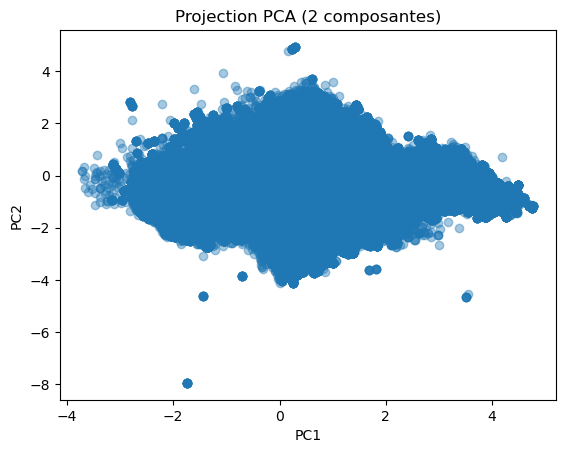

Variance expliquée : 40.11%


In [12]:
# PCA pour visualiser la structure des données
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_num = df.select_dtypes(include="number").dropna()
scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X_num)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_pca)

plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.4)
plt.title("Projection PCA (2 composantes)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()
print(f"Variance expliquée : {pca.explained_variance_ratio_.cumsum()[-1]:.2%}")

## 5. Préparation pour le Machine Learning

In [15]:
# Gestion des valeurs manquantes et encodage
# 1) Catégorielles → 'Unknown', numériques → moyenne
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna("Unknown")
for col in df.select_dtypes(include="number").columns:
    df[col] = df[col].fillna(df[col].mean())

# Drop datetime columns before encoding
datetime_cols = df.select_dtypes(include="datetime64").columns.tolist()
df = df.drop(columns=datetime_cols)
print(f"Dropped datetime columns: {datetime_cols}")

# 2) One-hot encoding
df_encoded = pd.get_dummies(df, drop_first=True)
print(f"Shape après encodage : {df_encoded.shape}")
print(df_encoded.columns.tolist()[:20], "...")

Dropped datetime columns: ['result_datetime', 'estimated_validation_datetime']
Shape après encodage : (427945, 1227)
['labid', 'turnaround_time_mins', 'age', 'admissionweight', 'lab_workload_last_hour', 'result_year', 'result_month', 'result_day', 'result_hour', 'result_weekday', 'validation_hour', 'labname_-basos', 'labname_-eos', 'labname_-lymphs', 'labname_-monos', 'labname_-polys', 'labname_24 h urine protein', 'labname_24 h urine urea nitrogen', 'labname_acetaminophen', 'labname_albumin'] ...


In [16]:
# Sélection des features par importance (Random Forest)
from sklearn.ensemble import RandomForestRegressor

X_all = df_encoded.drop(columns=["turnaround_time_mins"])
y_all = df_encoded["turnaround_time_mins"]

rf_selector = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_all, y_all)

importances = pd.Series(rf_selector.feature_importances_, index=X_all.columns)
print("Top 20 features :")
print(importances.sort_values(ascending=False).head(20))

Top 20 features :
target_enriched_05-07 - nuit                                                      0.416573
target_enriched_15-06 - matin                                                     0.179399
target_enriched_07-06 - soir                                                      0.084046
result_day                                                                        0.038264
result_weekday                                                                    0.031411
labid                                                                             0.024239
time_category_matin                                                               0.021387
target_enriched_30-04 - soir                                                      0.020545
validation_hour                                                                   0.018355
result_month                                                                      0.016213
admissionweight                                                         

In [17]:
# Features sélectionnées (issues de l'analyse Random Forest)
important_features = [
    "admissionweight_73.3",
    "age_Unknown",
    "recent_diagnosis_cardiovascular|ventricular disorders|congestive heart failure",
    "labid",
    "lab_workload_last_hour",
    "result_hour",
    "result_day",
    "labname_fio2",
    "recent_diagnosis_neurologic|seizures|seizures|status epilepticus",
    "labname_total co2",
    "result_weekday",
    "labname_temperature"
]

# Vérifier la disponibilité des features
missing = [f for f in important_features if f not in df_encoded.columns]
available = [f for f in important_features if f in df_encoded.columns]
print(f"Features disponibles : {len(available)}/{len(important_features)}")
if missing:
    print("Manquantes :", missing)

# Utiliser les features disponibles uniquement
final_features = available

Features disponibles : 10/12
Manquantes : ['admissionweight_73.3', 'age_Unknown']


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_encoded[final_features]
y = df_encoded["turnaround_time_mins"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train : {X_train.shape} | Test : {X_test.shape}")

Train : (342356, 10) | Test : (85589, 10)


## 6. Modèles de Machine Learning

### 6.1 Régression Linéaire

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print(f"Régression Linéaire – MAE  : {mean_absolute_error(y_test, y_pred_lr):.2f}")
print(f"Régression Linéaire – RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.2f}")
print(f"Régression Linéaire – R²   : {r2_score(y_test, y_pred_lr):.4f}")

Régression Linéaire – MAE  : 68.65
Régression Linéaire – RMSE : 749.91
Régression Linéaire – R²   : 0.0032


### 6.2 LightGBM

In [23]:
import lightgbm as lgb

lgbm = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05,
    max_depth=-1, subsample=0.8,
    colsample_bytree=0.8, random_state=42
)
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)

print(f"LightGBM – MAE  : {mean_absolute_error(y_test, y_pred_lgbm):.2f}")
print(f"LightGBM – RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_lgbm)):.2f}")
print(f"LightGBM – R²   : {r2_score(y_test, y_pred_lgbm):.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004557 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 562
[LightGBM] [Info] Number of data points in the train set: 342356, number of used features: 10
[LightGBM] [Info] Start training from score 64.559999
LightGBM – MAE  : 58.38
LightGBM – RMSE : 414.23
LightGBM – R²   : 0.6959


### 6.3 XGBoost

In [33]:
! pip install tensorflow

  Using cached tensorflow-2.21.0-cp312-cp312-manylinux_2_27_x86_64.whl.metadata (4.4 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-manylinux2010_x86_64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-manylinux2014_x86_64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached grpcio-1.80.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (3.8 kB)
  Using cached keras-3.14.1-py3-none-any.whl.metadata (6.3 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached optree-0.19

In [26]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500, learning_rate=0.05,
    max_depth=6, subsample=0.8,
    colsample_bytree=0.8, random_state=42,
    tree_method="hist"
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print(f"XGBoost – MAE  : {mean_absolute_error(y_test, y_pred_xgb):.2f}")
print(f"XGBoost – RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.2f}")
print(f"XGBoost – R²   : {r2_score(y_test, y_pred_xgb):.4f}")

XGBoost – MAE  : 52.24
XGBoost – RMSE : 364.82
XGBoost – R²   : 0.7641


### 6.4 CatBoost

In [31]:
# pip install catboost  # décommenter si nécessaire
from catboost import CatBoostRegressor

cat = CatBoostRegressor(
    iterations=500, learning_rate=0.05,
    depth=6, random_seed=42, verbose=0
)
cat.fit(X_train, y_train)
y_pred_cat = cat.predict(X_test)

print(f"CatBoost – MAE  : {mean_absolute_error(y_test, y_pred_cat):.2f}")
print(f"CatBoost – RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_cat)):.2f}")
print(f"CatBoost – R²   : {r2_score(y_test, y_pred_cat):.4f}")

CatBoost – MAE  : 57.27
CatBoost – RMSE : 424.06
CatBoost – R²   : 0.6812


## 7. Réseau de neurones (MLP)

### 7.1 MLP avec ReLU

In [34]:
# pip install tensorflow  # décommenter si nécessaire
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model_relu = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1)
])
model_relu.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_relu = model_relu.fit(
    X_train, y_train,
    epochs=100, batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop], verbose=0
)

y_pred_relu = model_relu.predict(X_test)
print(f"MLP ReLU – MAE  : {mean_absolute_error(y_test, y_pred_relu):.2f}")
print(f"MLP ReLU – RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_relu)):.2f}")
print(f"MLP ReLU – R²   : {r2_score(y_test, y_pred_relu):.4f}")

I0000 00:00:1778613044.686948  342730 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778613044.862261  342730 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778613048.039702  342730 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/iiboudi/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`in

2675/2675 ━━━━━━━━━━━━━━━━━━━━ 1s 456us/step
MLP ReLU – MAE  : 61.68
MLP ReLU – RMSE : 733.86
MLP ReLU – R²   : 0.0454


### 7.2 MLP avec LeakyReLU

/home/iiboudi/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2675/2675 ━━━━━━━━━━━━━━━━━━━━ 2s 551us/step
MLP LeakyReLU – MAE  : 61.58
MLP LeakyReLU – RMSE : 734.18
MLP LeakyReLU – R²   : 0.0446


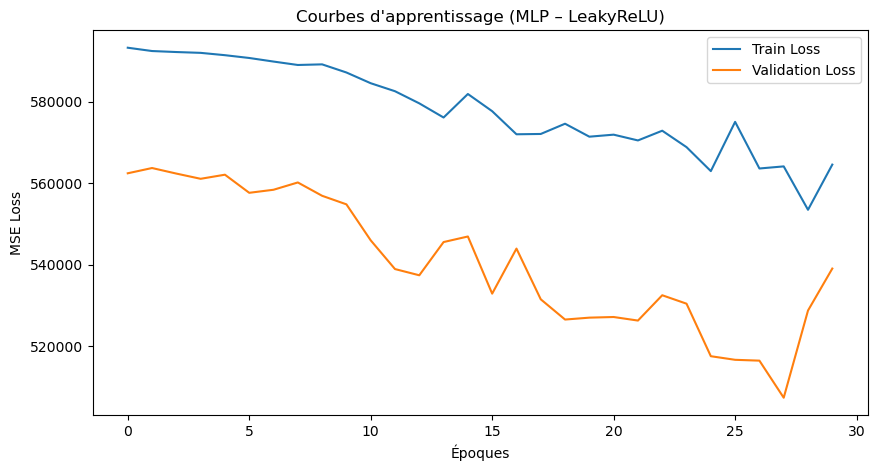

In [35]:
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.optimizers import Adam

# Note : Keras 3+ utilise `negative_slope` (anciennement `alpha`)
model_leaky = Sequential([
    Dense(256, input_shape=(X_train.shape[1],)),
    LeakyReLU(negative_slope=0.01),
    Dropout(0.4),
    Dense(128),
    LeakyReLU(negative_slope=0.01),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1)
])
model_leaky.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

history_leaky = model_leaky.fit(
    X_train, y_train,
    epochs=30, batch_size=32,
    validation_data=(X_test, y_test), verbose=0
)

y_pred_leaky = model_leaky.predict(X_test)
print(f"MLP LeakyReLU – MAE  : {mean_absolute_error(y_test, y_pred_leaky):.2f}")
print(f"MLP LeakyReLU – RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_leaky)):.2f}")
print(f"MLP LeakyReLU – R²   : {r2_score(y_test, y_pred_leaky):.4f}")

# Courbes d'apprentissage
plt.figure(figsize=(10, 5))
plt.plot(history_leaky.history['loss'],     label='Train Loss')
plt.plot(history_leaky.history['val_loss'], label='Validation Loss')
plt.title("Courbes d'apprentissage (MLP – LeakyReLU)")
plt.xlabel("Époques")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

## 8. Comparaison des modèles et visualisations

In [36]:
# Tableau récapitulatif des performances
results = pd.DataFrame({
    "Modèle": ["Régression Linéaire", "LightGBM", "XGBoost", "CatBoost", "MLP ReLU", "MLP LeakyReLU"],
    "MAE":  [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_lgbm),
        mean_absolute_error(y_test, y_pred_xgb),
        mean_absolute_error(y_test, y_pred_cat),
        mean_absolute_error(y_test, y_pred_relu),
        mean_absolute_error(y_test, y_pred_leaky),
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_lgbm)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
        np.sqrt(mean_squared_error(y_test, y_pred_cat)),
        np.sqrt(mean_squared_error(y_test, y_pred_relu)),
        np.sqrt(mean_squared_error(y_test, y_pred_leaky)),
    ],
    "R²": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_lgbm),
        r2_score(y_test, y_pred_xgb),
        r2_score(y_test, y_pred_cat),
        r2_score(y_test, y_pred_relu),
        r2_score(y_test, y_pred_leaky),
    ]
}).round(4)
print(results.sort_values("R²", ascending=False).to_string(index=False))

             Modèle     MAE     RMSE     R²
            XGBoost 52.2397 364.8216 0.7641
           LightGBM 58.3849 414.2338 0.6959
           CatBoost 57.2686 424.0623 0.6812
           MLP ReLU 61.6789 733.8580 0.0454
      MLP LeakyReLU 61.5795 734.1778 0.0446
Régression Linéaire 68.6469 749.9058 0.0032


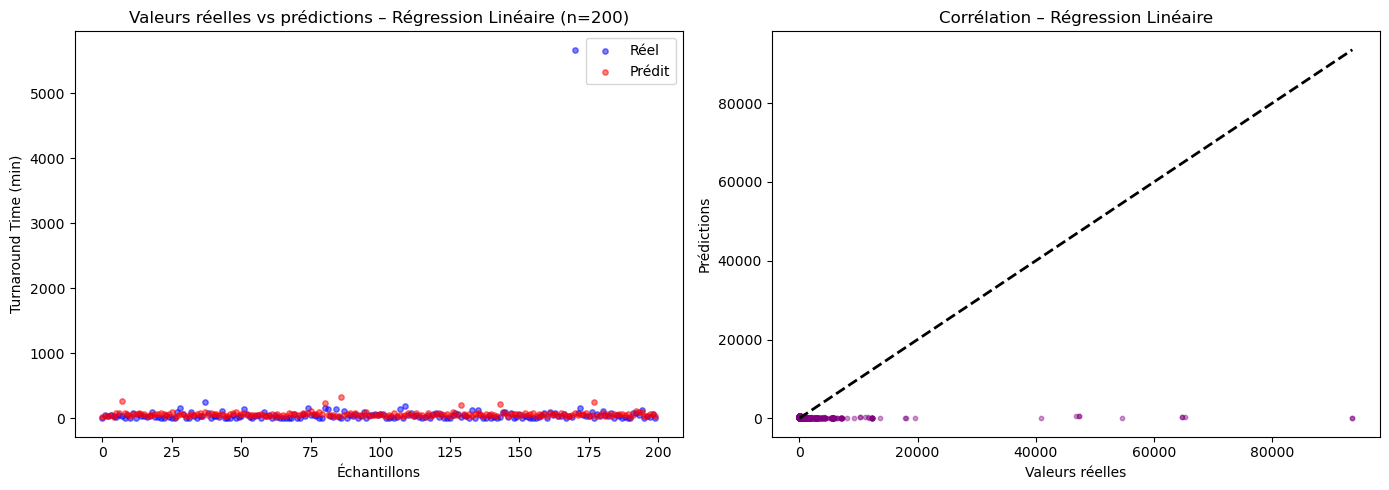

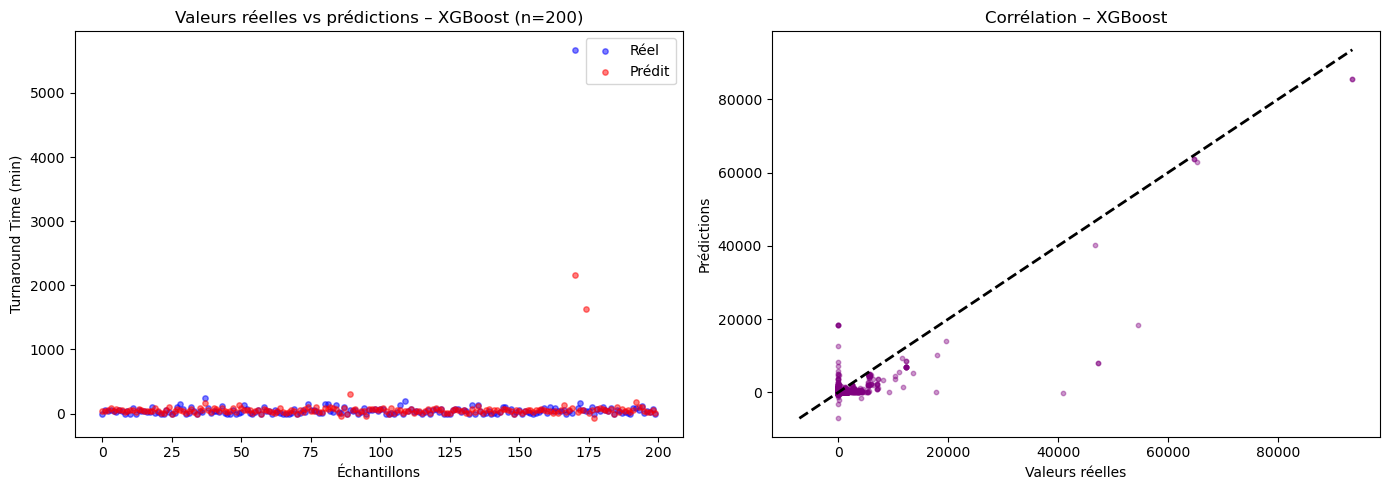

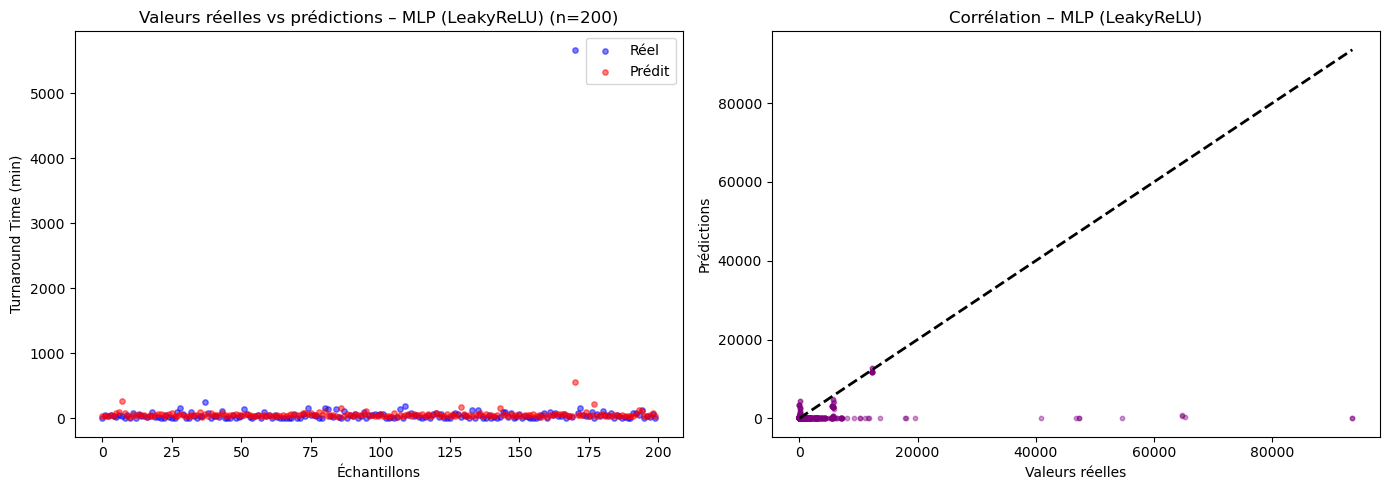

In [37]:
# Fonction utilitaire de visualisation
def plot_predictions(y_true, y_pred, model_name, limit=200):
    y_true = y_true.values if hasattr(y_true, 'values') else y_true
    y_pred = y_pred.flatten()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter temporel
    axes[0].scatter(range(limit), y_true[:limit], label="Réel",   color="blue", alpha=0.5, s=15)
    axes[0].scatter(range(limit), y_pred[:limit], label="Prédit",  color="red",  alpha=0.5, s=15)
    axes[0].set_title(f"Valeurs réelles vs prédictions – {model_name} (n={limit})")
    axes[0].set_xlabel("Échantillons")
    axes[0].set_ylabel("Turnaround Time (min)")
    axes[0].legend()

    # Corrélation réel vs prédit
    axes[1].scatter(y_true, y_pred, alpha=0.4, color="purple", s=10)
    mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    axes[1].plot([mn, mx], [mn, mx], 'k--', lw=2)
    axes[1].set_xlabel("Valeurs réelles")
    axes[1].set_ylabel("Prédictions")
    axes[1].set_title(f"Corrélation – {model_name}")

    plt.tight_layout()
    plt.show()

plot_predictions(y_test, y_pred_lr,    "Régression Linéaire")
plot_predictions(y_test, y_pred_xgb,   "XGBoost")
plot_predictions(y_test, y_pred_leaky, "MLP (LeakyReLU)")

## 9. Bonus – Classification de la période de sortie

On prédit la **catégorie de moment** de validation (matin / après-midi / soir / nuit).

In [38]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Features et target catégorielle
X_clf = df[["age", "admissionweight", "lab_workload_last_hour",
            "result_hour", "result_weekday"]].copy()
y_clf = df["turnaround_category"]

# Encodage
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_clf)

# Normalisation
scaler_clf = StandardScaler()
X_clf_scaled = scaler_clf.fit_transform(X_clf)

# Split
X_tr, X_te, y_tr, y_te = train_test_split(X_clf_scaled, y_encoded, test_size=0.2, random_state=42)
print(f"Classes : {encoder.classes_}")
print(f"Train : {X_tr.shape} | Test : {X_te.shape}")

Classes : ['apres_midi' 'matin' 'nuit' 'soir']
Train : (342356, 5) | Test : (85589, 5)


In [39]:
num_classes = len(encoder.classes_)

model_clf = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X_tr.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])
model_clf.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

history_clf = model_clf.fit(
    X_tr, y_tr,
    validation_data=(X_te, y_te),
    epochs=30, batch_size=32, verbose=0
)
loss, acc = model_clf.evaluate(X_te, y_te, verbose=0)
print(f"Accuracy test : {acc:.2%}")

/home/iiboudi/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy test : 94.14%


2675/2675 ━━━━━━━━━━━━━━━━━━━━ 2s 557us/step
              precision    recall  f1-score   support

  apres_midi       0.95      0.93      0.94     24472
       matin       0.93      0.95      0.94     21861
        nuit       0.94      0.94      0.94     17495
        soir       0.95      0.94      0.95     21761

    accuracy                           0.94     85589
   macro avg       0.94      0.94      0.94     85589
weighted avg       0.94      0.94      0.94     85589

Macro F1    : 0.9415
Weighted F1 : 0.9414


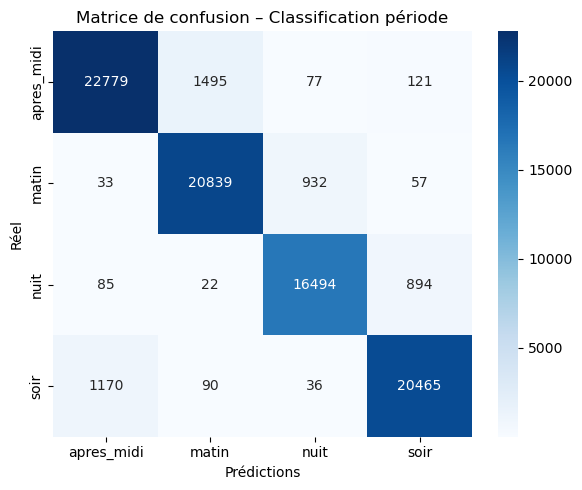

In [40]:
# Évaluation détaillée
y_pred_clf = model_clf.predict(X_te).argmax(axis=1)

print(classification_report(y_te, y_pred_clf, target_names=encoder.classes_))
print(f"Macro F1    : {f1_score(y_te, y_pred_clf, average='macro'):.4f}")
print(f"Weighted F1 : {f1_score(y_te, y_pred_clf, average='weighted'):.4f}")

cm = confusion_matrix(y_te, y_pred_clf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel("Prédictions")
plt.ylabel("Réel")
plt.title("Matrice de confusion – Classification période")
plt.tight_layout()
plt.show()

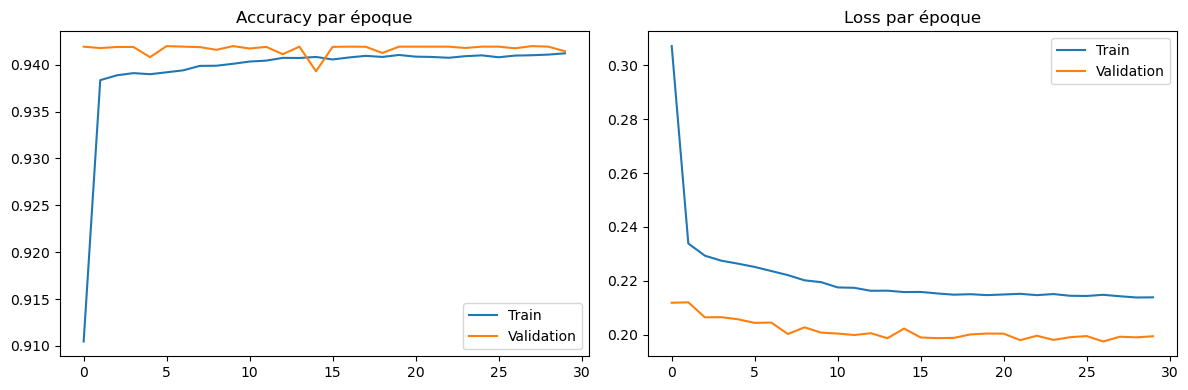

In [41]:
# Courbes d'apprentissage – classification
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_clf.history['accuracy'],     label='Train')
axes[0].plot(history_clf.history['val_accuracy'], label='Validation')
axes[0].set_title("Accuracy par époque")
axes[0].legend()

axes[1].plot(history_clf.history['loss'],     label='Train')
axes[1].plot(history_clf.history['val_loss'], label='Validation')
axes[1].set_title("Loss par époque")
axes[1].legend()

plt.tight_layout()
plt.show()

In [42]:
# Prédiction sur un exemple
exemple = pd.DataFrame({
    "age": [45],
    "admissionweight": [70],
    "lab_workload_last_hour": [25],
    "result_hour": [10],
    "result_weekday": [2]
})
exemple_scaled = scaler_clf.transform(exemple)
proba = model_clf.predict(exemple_scaled)[0]
classe = encoder.inverse_transform([proba.argmax()])[0]
print(f"Classe prédite : {classe}")
for c, p in zip(encoder.classes_, proba):
    print(f"  {c:12s} : {p:.2%}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Classe prédite : matin
  apres_midi   : 8.22%
  matin        : 91.52%
  nuit         : 0.04%
  soir         : 0.21%


## 10. Sauvegarde des modèles